# Project description

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

## Project instructions

1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample should be 10% of the initial dataset. 
4. Test the data using the test sample and provide a conclusion.

## Data description

The data is stored in file `taxi.csv`. The number of orders is in the '*num_orders*' column.

## Introduction

To predict the amount of taxi orders that Sweet Lift Taxi company will receive over the next hour, we are going to train and test a variety of models including machine learning and forecasting. To do this, we will first download and clean the data, resample it by one hour, perform exploratory data analysis, prepare the data for model training, train and test different models with different hyperparameters, and identify the model that acheives the lowest RMSE on the test set. We are aiming for an RMSE of <48. 

## Preparation

In [1]:
# Install into *this* notebook's Python (avoids "wrong environment" import errors).
%pip install pmdarima -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from numpy.random import RandomState
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from pmdarima import auto_arima

First we'll read in the data and take a look.

In [3]:
# Read in data
data = pd.read_csv(
    '/Users/rathiramasamy/Downloads/taxi.csv', index_col=[0], parse_dates=[0]
)

# Sort index
data.sort_index(inplace=True)

# Look at sample, info, and whether data is monotonic
data.info()
print(data.index.is_monotonic_increasing)
data.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB
True


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


The data now has the date column set to the index in datetime format, and is sorted in order and mnonotonic. We can see that this data spans March 2018 through August 2018, and it looks like we have data in 10-minute intervals. We'll check if there are any duplicate timestamps, and verify the interval. 

In [4]:
# Check for duplicate timestamps
print(data.index.duplicated().sum())

# Verify current frequency
data.index.inferred_freq

0


'10min'

We can see there are no duplicates, and the frequency is indeed 10-minute intervals. We're ready to resample the data by one hour.

In [5]:
# Resample data by 1 hour
data = data.resample('1H').sum() 

# Look at sample and info
print(data.head())
data.info()

                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


/var/folders/m0/21gqf6qx3td5gjtyyyz2wvtw0000gn/T/ipykernel_72235/1234689759.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data = data.resample('1H').sum()


We can now see the total number of taxi orders by the hour. We'll move on to some exploratory data analysis.

## Analysis

We'll start by calling describe and plotting our data to take a look at it.

In [6]:
# Call summary stats
data.describe()

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


We have 4,416 records. The minimum number of orders is 0 (which would make sense for certain times of day) with a max of 462 and mean of 84. 

<Axes: xlabel='datetime'>

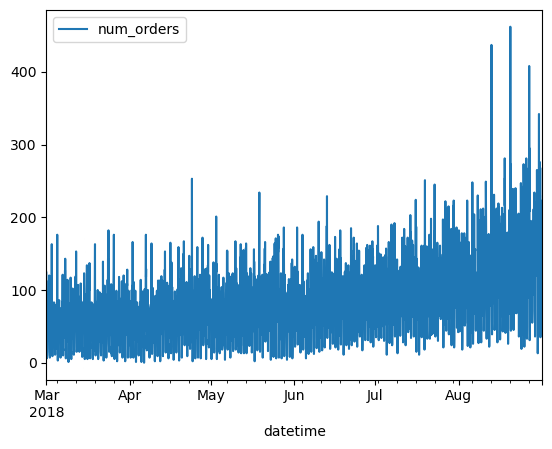

In [7]:
# Plot data
data.plot()

From March to August, it looks like the mean number of taxi orders is gradually increasing. This could be explained by the popularity of summer travel. The variation/standard deviation is also increasing. There appears to be some seasonality with frequent spikes and repeating patterns, which makes sense when considering how patterns of travel can increase and decrease depending on the season, time of day an day of the week. Adding these features will likely be helpful for model training.

It looks like there are some spikes in taxi orders in August. Because there are several spikes, these are probably not random errors but rather corresponding to high-demand periods e.g., August weekends. 

Based on the above plot, the data appears to be non-stationary. Next, we'll take a look at the rolling mean.

<Axes: xlabel='datetime'>

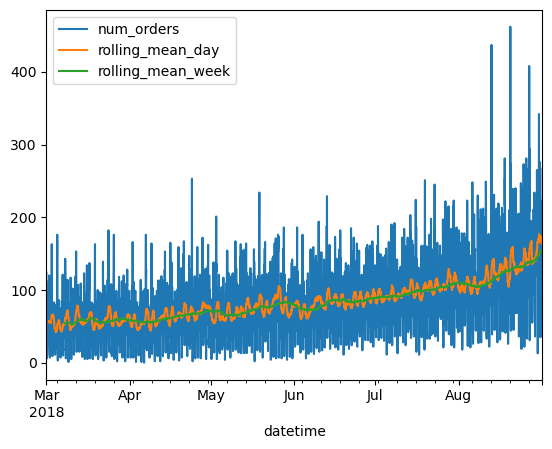

In [8]:
# Daily and weekly rolling means of num_orders
data['rolling_mean_day'] = data['num_orders'].rolling(24).mean()
data['rolling_mean_week'] = data['num_orders'].rolling(168).mean()

# Plot data with rolling means
data.plot()

Here we can see the time series smoothed out over daily and weekly windows. The daily rolling mean appears to spike up and down, showing daily variation. This smooths out for the weekly rolling mean, showing that demand steadily rises from March to August. 

Looking at these, it will be useful to include hour of the day, day of the week, and month as features for model training.

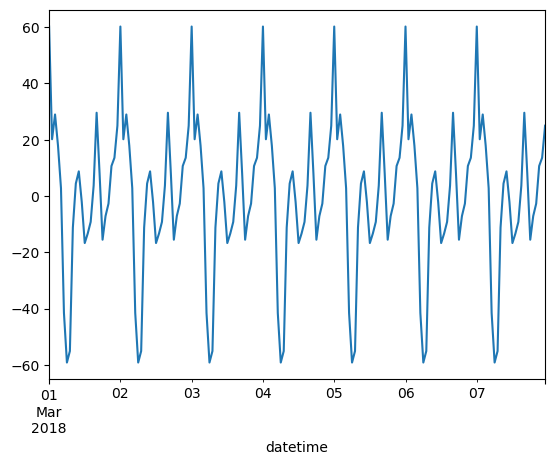

In [9]:
# Look at seasonal decomposition
decomposed = seasonal_decompose(data['num_orders'])

# Plot seasonality
decomposed.seasonal['2018-03-01':'2018-03-07'].plot()
plt.show()


Looking at a 1-week slice of the data, we can see a daily cycle that repeats and shows large shifts in demand based on time of day. The daily shape looks pretty much the same day over day, so day of the week effects don't seem as strong. It looks like early morning is fairly slow, then peaks a few times during the day, which the highest demand during the very late night/overnight. This makes sense as this window of time is when travelers are most reliant on taxi services vs. an alternative like public transit or family.  

## Training

We will explore and test many different models, including machine learning models (Linear Regression, Random Forest, LightGBM, CatBoost, and XGBoost) and forecasting models. 

We'll start with machine learning models. To properly train these models, we'll first need to prepare by creating features in our dataset. 

The test set needs to be 10% of the original dataset.

In [10]:
# Drop EDA rolling mean columns
data = data.drop(columns=['rolling_mean_day', 'rolling_mean_week'])

# Calculate test size
test_size = int(.1*len(data))

In [11]:
# Define function to make features
def make_features(data, max_lag):
    # Create a copy of the data
    data = data.copy()
    
    # Hour, day of week, month
    data['hour'] = data.index.hour
    data['dow'] = data.index.dayofweek
    data['month'] = data.index.month

    # Rolling means
    data['rolling_mean_day'] = data['num_orders'].rolling(24).mean().shift(1)
    data['rolling_mean_week'] = data['num_orders'].rolling(168).mean().shift(1)
    # Rolling standard deviation
    data['rolling_std_day'] = data['num_orders'].rolling(24).std().shift(1)
    data['rolling_std_week'] = data['num_orders'].rolling(168).std().shift(1)

    # Lags
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    # Return features
    return data


In [16]:
# Run function to create features
data = make_features(data,24)


In [17]:
# Drop rows with NaN values
data = data.dropna()

Now that we've created features and gotten rid of missing values, we can go ahead and split the data into training and test sets.

In [18]:
# Split data into train and test sets
train, test = train_test_split(data, shuffle=False, test_size=test_size)

# Define features and target
features_train = train.drop('num_orders', axis=1)
target_train = train['num_orders']

features_test = test.drop('num_orders', axis=1)
target_test = test['num_orders']

We'll start with a Linear Regression model.

In [19]:
# Train model
model = LinearRegression()
model.fit(features_train, target_train)

pred_train = model.predict(features_train)
pred_test = model.predict(features_test)

print("RMSE for the training set:", np.sqrt(mean_squared_error(target_train, pred_train)))
print("RMSE for the test set: ", np.sqrt(mean_squared_error(target_test, pred_test)))


RMSE for the training set: 25.801769864569305
RMSE for the test set:  45.143569626543126


This first model fulfills our RMSE requirement of <48 on the test set; we'll see if we can acheive an even lower RMSE with subsequent models.

Next we'll try a Random Forest model. We'll use GridSearch to tune hyperparameters on the training set include number of trees and tree depth.

In [20]:
# Set up model
rf = RandomForestRegressor(random_state=19)

# Set up grid for tuning
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 14]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=2,
    n_jobs=1,      
    verbose=2
)

grid_search.fit(features_train, target_train)

best_model_rf = grid_search.best_estimator_
best_result = -grid_search.best_score_
best_params = grid_search.best_params_

pred_test_rf = best_model_rf.predict(features_test)

print("Best RMSE for training set:", best_result)
print("Best parameters:", best_params)
print("RMSE for the test set:", np.sqrt(mean_squared_error(target_test, pred_test_rf)))

Fitting 2 folds for each of 4 candidates, totalling 8 fits
[CV] END ......................max_depth=10, n_estimators=50; total time=   0.6s
[CV] END ......................max_depth=10, n_estimators=50; total time=   0.5s
[CV] END .....................max_depth=10, n_estimators=100; total time=   1.1s
[CV] END .....................max_depth=10, n_estimators=100; total time=   1.1s
[CV] END ......................max_depth=14, n_estimators=50; total time=   0.7s
[CV] END ......................max_depth=14, n_estimators=50; total time=   0.7s
[CV] END .....................max_depth=14, n_estimators=100; total time=   1.3s
[CV] END .....................max_depth=14, n_estimators=100; total time=   1.3s
Best RMSE for training set: 26.314861742804716
Best parameters: {'max_depth': 14, 'n_estimators': 100}
RMSE for the test set: 41.00610481421159


After tuning hyperparameters using the training set, our best Random Forest model performed slightly better than Linear Regression on the test set.

Next, we'll try a LightGBM model.

In [21]:
# Set up model
lgbm = LGBMRegressor(
    objective='regression',
    random_state=19,
    n_jobs=1,
    verbose=-1
)

# Set up grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'num_leaves': [31, 63]
}

grid_search_lgbm = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=2,
    n_jobs=1,
    verbose=2
)

grid_search_lgbm.fit(features_train,target_train)

best_lgbm_model = grid_search_lgbm.best_estimator_
best_lgbm_rmse = -grid_search_lgbm.best_score_
best_lgbm_params = grid_search_lgbm.best_params_

pred_test_lgbm = best_lgbm_model.predict(features_test)

print("Best RMSE for training set:", best_lgbm_rmse)
print("Best parameters:", best_lgbm_params)
print("RMSE for the test set:", np.sqrt(mean_squared_error(target_test, pred_test_lgbm)))


Fitting 2 folds for each of 16 candidates, totalling 32 fits
[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, num_leaves=31; total time=   0.0s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, num_leaves=31; total time=   0.0s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, num_leaves=63; total time=   0.0s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, num_leaves=63; total time=   0.0s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=300, num_leaves=31; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=300, num_leaves=31; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=300, num_leaves=63; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=300, num_leaves=63; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=6, n_estimators=100, num_leaves=31; total time=   0.0s
[CV] END learning_rate=0.05, max_depth=6, n_estimators=100, num_leaves=31; total time=   0.0s

The best LightGBM model performed slightly better than Linear Regression but not quite as well as Random Forest.

Now we'll look at CatBoost and XGBoost.

In [22]:
# Train CatBoost model
cat_model = CatBoostRegressor(
    loss_function='RMSE',
    random_seed=19,
    verbose=0
)
# Set up grid for tuning
param_grid_cat = {
    'iterations': [100, 300],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6]
}

grid_search_cat = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid_cat,
    scoring='neg_root_mean_squared_error',
    cv=2,
    n_jobs=1,
    verbose=2
)

grid_search_cat.fit(features_train,target_train)

best_cat_model = grid_search_cat.best_estimator_
best_cat_rmse = -grid_search_cat.best_score_
best_cat_params = grid_search_cat.best_params_

pred_test_cat = best_cat_model.predict(features_test)

print("Best RMSE for training set:", best_cat_rmse)
print("Best parameters:", best_cat_params)
print("RMSE for the test set:", np.sqrt(mean_squared_error(target_test, pred_test_cat)))

Fitting 2 folds for each of 8 candidates, totalling 16 fits
[CV] END ........depth=4, iterations=100, learning_rate=0.05; total time=   0.1s
[CV] END ........depth=4, iterations=100, learning_rate=0.05; total time=   0.0s
[CV] END .........depth=4, iterations=100, learning_rate=0.1; total time=   0.0s
[CV] END .........depth=4, iterations=100, learning_rate=0.1; total time=   0.0s
[CV] END ........depth=4, iterations=300, learning_rate=0.05; total time=   0.1s
[CV] END ........depth=4, iterations=300, learning_rate=0.05; total time=   0.1s
[CV] END .........depth=4, iterations=300, learning_rate=0.1; total time=   0.1s
[CV] END .........depth=4, iterations=300, learning_rate=0.1; total time=   0.1s
[CV] END ........depth=6, iterations=100, learning_rate=0.05; total time=   0.1s
[CV] END ........depth=6, iterations=100, learning_rate=0.05; total time=   0.1s
[CV] END .........depth=6, iterations=100, learning_rate=0.1; total time=   0.1s
[CV] END .........depth=6, iterations=100, learni

In [23]:
# Train and fit model
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=19,
    n_jobs=1,
    verbosity=0
)
# Set up grid for tuning
param_grid_xgb = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring='neg_root_mean_squared_error',
    cv=2,
    n_jobs=1,
    verbose=2
)

grid_search_xgb.fit(features_train, target_train)

best_xgb_model = grid_search_xgb.best_estimator_
best_xgb_rmse = -grid_search_xgb.best_score_
best_xgb_params = grid_search_xgb.best_params_

pred_test_xgb = best_xgb_model.predict(features_test)

print("Best RMSE for training set:", best_xgb_rmse)
print("Best parameters:", best_xgb_params)
print("RMSE for the test set:", np.sqrt(mean_squared_error(target_test, pred_test_xgb)))

Fitting 2 folds for each of 16 candidates, totalling 32 fits
[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=300, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=300, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=300, subsample=1.0; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=300, subsample=1.0; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=6, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.05, max_depth=6, n_estimators=100, subsample=0.8; total time=   0.1s

All the gradient boosting models performed quite well; however, Random Forest performed the best (by a very slim margin) out of all the machine learning models based on an RMSE of 41.0. 

Though the above models demonstrate that machine learning can adequately handle Sweet Lift Taxi's task, it's worth exploring whether forecasting models might do even better. We'll use the auto_arima function from pmdarima to quickly identify the best forecasting model from ARIMA-family models as well as the best parameters for that model. We'll set seasonality as true and look at daily seasonality (over a 24-hour period) based on the seasonal decomposition graph we examined in the earlier EDA step. 

In [24]:
# Find optimal ARIMA-family model for our data
arima_model = auto_arima(
    target_train,
    seasonal=True,
    m=24,  # seasonality
    trace=True,
    stepwise=True
)

# Get info about the best model
print(arima_model.summary())

# Make predictions
pred_auto_arima = arima_model.predict(len(target_test))

# Evaluate the model predictions compared to the test set using RMSE
auto_arima_rmse = np.sqrt(mean_squared_error(target_test, pred_auto_arima))
print(auto_arima_rmse)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=8.37 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=38156.186, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=36752.168, Time=1.14 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=36880.251, Time=1.94 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=38154.186, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[24] intercept   : AIC=37804.495, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[24] intercept   : AIC=inf, Time=9.12 sec
 ARIMA(1,1,0)(1,0,1)[24] intercept   : AIC=inf, Time=3.08 sec
 ARIMA(1,1,0)(0,0,1)[24] intercept   : AIC=37201.695, Time=1.32 sec
 ARIMA(1,1,0)(2,0,1)[24] intercept   : AIC=inf, Time=16.57 sec
 ARIMA(0,1,0)(1,0,0)[24] intercept   : AIC=37469.945, Time=0.69 sec
 ARIMA(2,1,0)(1,0,0)[24] intercept   : AIC=36529.208, Time=2.14 sec
 ARIMA(2,1,0)(0,0,0)[24] intercept   : AIC=37744.558, Time=0.05 sec
 ARIMA(2,1,0)(2,0,0)[24] intercept   : AIC=inf, Time=14.08 sec
 ARIMA(2,1,0)(1,0,1)[24] intercep

The best model was an ARIMA model looking at 5 past values, a differencing of 1, and zero prediction errors. This differencing makes sense considering the data was non-stationary. However, this best model only acheived an RMSE of 59.9 on the test set, which is worse than the ML models and does not clear our threshold of <48. 

## Conclusion

In this case, machine learning models performed better at predicting the number of taxi orders by the hour than forecasting models. Creating features including hour, day of the week, month, rolling mean, rolling std, and lags likely helped these ML models perform well on this task. 

Of the ML models, Random Forest technically acheived the lowest RMSE at 41.0. However, all ML models achieved RMSEs under 48 on the test set, and the differences between them were not significant. In this case, based on the above training and testing I'd likely recommend a gradient boosting model for Sweet Lift Taxi due to speed and scalability. These models might perform even better if trained on more data. A full year of data (or even multiple years) would provide a clearer pattern of taxi usage based on the month. The current data shows a relatively steep jump in the last month available, and it would be useful for model training to see if this upward trend continues through the end of the year, or if there is a predictable rise and fall according to time of year.

